# Assignment: Linear Models
## Do three questions.
### `! git clone https://github.com/ds4e/linearModels`

In [59]:
# i did questions 1, 2, and 4

**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?
2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (This is a trick question, and the trick involves how you handle the intercept of the model.)
3. Can linear regression be used for classification? Explain why, or why not.
4. What are signs that your linear model is over-fitting?
5. Clearly explain multi-colinearity using the two-stage least squares technique.
6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?
7. What is the interpretation of the intercept? A slope coefficient for a variable? The coefficient for a dummy/one-hot-encoded variable?

**Question 1.**



1.   A model is considered linear when it is linear in its parameters, where the dependent variable is expressed as a linear combination of the model's coefficients that are then multiplied by the independent variables and added up. For example, $y = \beta_0 + \beta_1 x_1 + \beta_2, is linear in the coefficients as they are only to the first power and are not multiplied by each other. Linear means lindear in the unknown parameters being estimated, not necessarily the relationship between the dependent and independent variables.
2.   This depends on whether the model includes an intercept. If there is an intercept, one category has to be left out as the reference group. Then the coefficient on a dummy variable tells you how much higher or lower that category is compared to the omitted category, holding everything else constant. If there is no intercept, then each dummy coefficient represents the predicted value for that category itself. The trick is that the interpretation changes depending on how the intercept is handled.
3.  Linear regression can technically be used for classification by predicting a number and then using a cutoff, but it is usually not a good choice. This is because classification outcomes are often categories like 0 and 1, while linear regression is designed for continuous outcomes. It can also predict values below 0 or above 1, which do not make sense as probabilities. Models like logistic regression are usually better because they are designed for classification problems.
4.  A linear model may be over-fitting if it does extremely well on the training data but performs much worse on new or test data. Other signs include very unstable coefficients, overly complicated models with too many variables, and coefficients that seem unreasonable or change a lot when the data changes slightly. Over-fitting usually means the model is capturing noise instead of the true relationship.
5.  Multicollinearity occurs when one explanatory variable is closely linked to other explanatory variables in the model. Breaking it down, the first step regresses one variable against all the others. If this initial regression accounts for most of the variation in that variable, it means there's not much unique information left to work with. This makes it tricky to distinguish its effect from the effects of the other variables. As a result, the coefficient estimates can become unstable, and the standard errors end up larger.
6.  You can include nonlinear relationships by transforming variables or adding transformed terms to the model. For example, you can add squared terms, cubic terms, interaction terms, or logarithms. This lets the model capture curves and more complicated patterns while still using linear regression methods. So even if the relationship between x and y is nonlinear, the model can still handle it if it stays linear in the coefficients.
7.  The intercept is the predicted value of y when all the explanatory variables are equal to zero. A slope coefficient tells you how much the predicted value of y changes when that variable increases by one unit, holding all other variables constant. A dummy variable coefficient tells you the difference in predicted y between that category and the reference category if there is an intercept. If there is no intercept, then it represents the predicted value for that category itself.








**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood `: The bourough of NYC. Note the space, or rename the variable.
- `Property Type`: The kind of dwelling
- `Room Type`: The kind of space being rented

1. Compute the average prices and scores by `Neighbourhood `; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood `.
2. Regress price on `Neighbourhood ` by creating the appropriate dummy/one-hot-encoded variables, without an intercept in the linear model and using all the data. Compare the coefficients in the regression to the table from part 1. What pattern do you see? What are the coefficients in a regression of a continuous variable on one categorical variable?
3. Repeat part 2, but leave an intercept in the linear model. How do you have to handle the creation of the dummies differently? What is the intercept? Interpret the coefficients. How can I get the coefficients in part 2 from these new coefficients?
4. Split the sample 80/20 into a training and a test set. Run a regression of `Price` on `Review Scores Rating` and `Neighbourhood `. What is the $R^2$ and RMSE on the test set? What is the coefficient on `Review Scores Rating`? What is the most expensive kind of property you can rent?
5. Split the sample 80/20 into a training and a test set. Run a regression of `Price` on `Review Scores Rating` and `Neighbourhood ` and `Property Type`. What is the $R^2$ and RMSE on the test set? What is the coefficient on `Review Scores Rating`? What is the most expensive kind of property you can rent?
6. What does the coefficient on `Review Scores Rating` mean if it changes from part 4 to 5? Hint: Think about how multilple linear regression works.
7. (Optional) We've included `Neighborhood ` and `Property Type` separately in the model. How do you interact them, so you can have "A bedroom in Queens" or "A townhouse in Manhattan". Split the sample 80/20 into a training and a test set and run a regression including that kind of "property type X neighborhood" dummy, plus `Review Scores Rating`. How does the slope coefficient for `Review Scores Rating`, the $R^2$, and the RMSE change? Do they increase significantly compares to part 5? Are the coefficients in this regression just the sum of the coefficients for `Neighbourhood ` and `Property Type` from 5? What is the most expensive kind of property you can rent?

In [71]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Loading the CSV file into a pandas DataFrame
df_airbnb = pd.read_csv('/content/linearModels/data/Q1_clean.csv')

# Displaying the first 5 rows
print("First 5 rows of df_airbnb:")
print(df_airbnb.head())

# print info to check data types and non-null counts
print("\nDataFrame Info:")
df_airbnb.info()

# Explicitly check for the 'Neighbourhood ' column with trailing space
if 'Neighbourhood ' in df_airbnb.columns:
    print("\n'Neighbourhood ' column with trailing space successfully identified.")
else:
    print("\n'Neighbourhood ' column not found as expected. Columns are:", df_airbnb.columns.tolist())

# Confirm basic statistics for Price and Review Scores Rating
print("\nDescriptive statistics for Price and Review Scores Rating:")
print(df_airbnb[['Price', 'Review Scores Rating']].describe())

First 5 rows of df_airbnb:
   Price  Review Scores Rating Neighbourhood  Property Type        Room Type
0    549                  96.0      Manhattan     Apartment     Private room
1    149                 100.0       Brooklyn     Apartment  Entire home/apt
2    250                 100.0      Manhattan     Apartment  Entire home/apt
3     90                  94.0       Brooklyn     Apartment     Private room
4    270                  90.0      Manhattan     Apartment  Entire home/apt

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22153 entries, 0 to 22152
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Price                 22153 non-null  int64  
 1   Review Scores Rating  22153 non-null  float64
 2   Neighbourhood         22153 non-null  object 
 3   Property Type         22153 non-null  object 
 4   Room Type             22153 non-null  object 
dtypes: float64(1), int64(1),

Average Price and Review Scores Rating by Neighbourhood:
                     Price  Review Scores Rating
Neighbourhood                                   
Bronx            75.276498             91.654378
Brooklyn        127.747378             92.363497
Manhattan       183.664286             91.801496
Queens           96.857233             91.549057
Staten Island   146.166667             90.843750

The most expensive borough on average is: Manhattan with an average price of 183.66


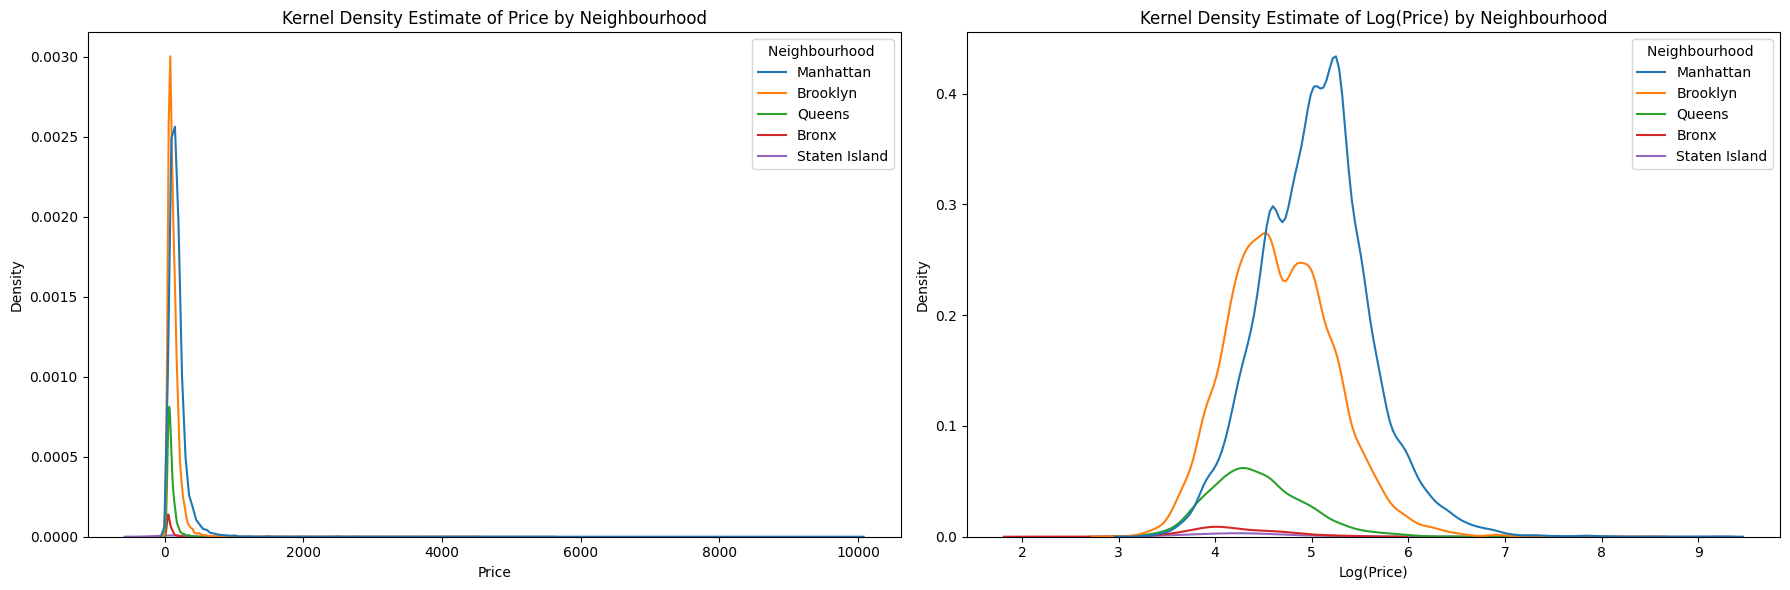

In [61]:
# 2.1
# Correcting the column name to include the trailing space
grouped_data = df_airbnb.groupby('Neighbourhood ')[['Price', 'Review Scores Rating']].mean()
print("Average Price and Review Scores Rating by Neighbourhood:")
print(grouped_data)

most_expensive_borough = grouped_data['Price'].idxmax()
highest_avg_price = grouped_data['Price'].max()
print(f"\nThe most expensive borough on average is: {most_expensive_borough} with an average price of {highest_avg_price:.2f}")

# Create log_Price column
df_airbnb['log_Price'] = np.log(df_airbnb['Price'])

# setting up the plots
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Kernel density plot for Price
sns.kdeplot(data=df_airbnb, x='Price', hue='Neighbourhood ', ax=axes[0])
axes[0].set_title('Kernel Density Estimate of Price by Neighbourhood')
axes[0].set_xlabel('Price')
axes[0].set_ylabel('Density')

# Kernel density plot for log_Price
sns.kdeplot(data=df_airbnb, x='log_Price', hue='Neighbourhood ', ax=axes[1])
axes[1].set_title('Kernel Density Estimate of Log(Price) by Neighbourhood')
axes[1].set_xlabel('Log(Price)')
axes[1].set_ylabel('Density')

plt.tight_layout()
plt.show()

In [62]:
# 2.2
# making dummies for all categories
neigh_dummies = pd.get_dummies(df_airbnb['Neighbourhood '], drop_first=False, dtype=int)

# Regression without intercept:
X = neigh_dummies
y = df_airbnb['Price']

reg = LinearRegression(fit_intercept=False)
reg.fit(X, y)

print("Regression Coefficients (without intercept):")
print(pd.Series(reg.coef_, index=X.columns))


'''
For part 2, the regression coefficients are exactly the same as the average price in each neighborhood.
This happens because the model uses only neighborhood dummy variables and does not include an intercept.
In that setup, each coefficient must represent the mean price for its own category.
So the coefficient for Bronx equals the average Bronx price, the coefficient for Brooklyn equals the average Brooklyn price, and so on.
 In general, when a continuous variable is regressed on one categorical variable using dummies and no intercept, the coefficients are just the group means.
'''

Regression Coefficients (without intercept):
Bronx             75.276498
Brooklyn         127.747378
Manhattan        183.664286
Queens            96.857233
Staten Island    146.166667
dtype: float64


' \nFor part 2, the regression coefficients are exactly the same as the average price in each neighborhood. \nThis happens because the model uses only neighborhood dummy variables and does not include an intercept. \nIn that setup, each coefficient must represent the mean price for its own category. \nSo the coefficient for Bronx equals the average Bronx price, the coefficient for Brooklyn equals the average Brooklyn price, and so on.\n In general, when a continuous variable is regressed on one categorical variable using dummies and no intercept, the coefficients are just the group means.\n'

In [63]:
# 2.3
neigh_dummies2 = pd.get_dummies(df_airbnb['Neighbourhood '], drop_first=True, dtype=int)
X = neigh_dummies2
y = df_airbnb['Price']

reg2 = LinearRegression(fit_intercept=True)
reg2.fit(X, y)

print("Intercept:", reg2.intercept_)
print("Regression Coefficients (with intercept and one dummy dropped):")
print(pd.Series(reg2.coef_, index=X.columns))


'''
For part 3, once an intercept is included in the regression, one neighborhood dummy has to be dropped to avoid perfect multicollinearity. In my model, the Bronx was omitted, so it becomes the reference category.
The intercept therefore represents the average price in the Bronx, about $75.28. Each of the other coefficients shows how much more expensive that neighborhood is compared to the Bronx.
For example, the coefficient for Brooklyn means that listings in Brooklyn cost about $52.47 more on average than listings in the Bronx, while the coefficient for Manhattan means listings there cost about $108.39 more than in the Bronx.

The coefficients from part 2 can be recovered from this model by adding the intercept to each neighborhood coefficient.
So the intercept gives the Bronx mean, and the other neighborhood means are found by taking the Bronx mean plus each neighborhood’s coefficient.
This shows that with no intercept, the coefficients are the group means, while with an intercept, the coefficients are differences relative to the omitted reference category.
'''

Intercept: 75.27649769585331
Regression Coefficients (with intercept and one dummy dropped):
Brooklyn          52.470881
Manhattan        108.387789
Queens            21.580735
Staten Island     70.890169
dtype: float64


' \nFor part 3, once an intercept is included in the regression, one neighborhood dummy has to be dropped to avoid perfect multicollinearity. In my model, the Bronx was omitted, so it becomes the reference category.\nThe intercept therefore represents the average price in the Bronx, about $75.28. Each of the other coefficients shows how much more expensive that neighborhood is compared to the Bronx. \nFor example, the coefficient for Brooklyn means that listings in Brooklyn cost about $52.47 more on average than listings in the Bronx, while the coefficient for Manhattan means listings there cost about $108.39 more than in the Bronx.\n\nThe coefficients from part 2 can be recovered from this model by adding the intercept to each neighborhood coefficient. \nSo the intercept gives the Bronx mean, and the other neighborhood means are found by taking the Bronx mean plus each neighborhood’s coefficient. \nThis shows that with no intercept, the coefficients are the group means, while with an 

In [64]:
#2.4

# Prepare features and target variable for Q2 Part 4
X = df_airbnb[['Review Scores Rating', 'Neighbourhood ']]
y = df_airbnb['Price']

# spliting the data into training and test sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Creating dummy variables for 'Neighbourhood ' in the training set
X_train_dummies = pd.get_dummies(X_train['Neighbourhood '], drop_first=True, dtype=int)
X_train_processed = pd.concat([X_train[['Review Scores Rating']], X_train_dummies], axis=1)

# Creating dummy variables for 'Neighbourhood ' in the test set
train_neigh_cols = X_train_dummies.columns
X_test_dummies = pd.get_dummies(X_test['Neighbourhood '], drop_first=True, dtype=int)
# Reindex test dummies to match training columns, filling missing with 0
X_test_dummies = X_test_dummies.reindex(columns=train_neigh_cols, fill_value=0)
X_test_processed = pd.concat([X_test[['Review Scores Rating']], X_test_dummies], axis=1)

# Instantiate and training the Linear Regression model
model_q2_part4 = LinearRegression()
model_q2_part4.fit(X_train_processed, y_train)

#predictions on the test set
y_pred_q2_part4 = model_q2_part4.predict(X_test_processed)

# calculating R-squared and RMSE on the test set
r2_q2_part4 = r2_score(y_test, y_pred_q2_part4)
rmse_q2_part4 = np.sqrt(mean_squared_error(y_test, y_pred_q2_part4))

print(f"R-squared on the test set: {r2_q2_part4:.4f}")
print(f"RMSE on the test set: {rmse_q2_part4:.4f}")

# Extracting the coefficient for 'Review Scores Rating'
review_score_coef_index = X_train_processed.columns.get_loc('Review Scores Rating')
review_score_coefficient_q2_part4 = model_q2_part4.coef_[review_score_coef_index]

print(f"Coefficient for 'Review Scores Rating': {review_score_coefficient_q2_part4:.4f}")

# Determine the most expensive kind of property (Neighbourhood), with intercept representing the baseline (Bronx, with 'Review Scores Rating' assumed 0 for baseline calculation)
# need to find the combination of 'Neighbourhood' that maximizes price with the max possible score (100.0).
intercept_q2_part4 = model_q2_part4.intercept_
max_review_score = 100.0

# Base predicted price if 'Review Scores Rating' is 100 and all dummy variables are 0 (i.e., for the reference category Bronx)
base_predicted_price = intercept_q2_part4 + (review_score_coefficient_q2_part4 * max_review_score)

# Creating a dictionary to store predicted prices for each neighbourhood
predicted_prices_by_neigh = {}

# reference category (Bronx) is typically the one 'dropped' when drop_first=True [bronx alphabetically first]
reference_neighbourhood = 'Bronx'
predicted_prices_by_neigh[reference_neighbourhood] = base_predicted_price

# Getting the coefficients for the dummy variables (excluding 'Review Scores Rating')
dummy_coefs = pd.Series(model_q2_part4.coef_, index=X_train_processed.columns).drop('Review Scores Rating', errors='ignore')

# Addong the coefficients of other neighbourhoods to the base predicted price
for neigh_name, coef_value in dummy_coefs.items():
    predicted_prices_by_neigh[neigh_name] = base_predicted_price + coef_value

# Find the neighbourhood with the highest predicted price
most_expensive_neighbourhood = max(predicted_prices_by_neigh, key=predicted_prices_by_neigh.get)
highest_predicted_price = predicted_prices_by_neigh[most_expensive_neighbourhood]

print(f"The most expensive kind of property (with a {max_review_score} Review Score) is in: {most_expensive_neighbourhood} with a predicted price of {highest_predicted_price:.2f}")

'''
The regression of Price on Review Scores Rating and Neighbourhood produced a test-set R^2 of 0.0459 and an RMSE of 140.92, so the model does not explain much of the variation in price.
 The coefficient on Review Scores Rating is 1.2119, meaning that a 1-point increase in review score is associated with about a $1.21 increase in predicted price, holding neighborhood fixed.
The model predicts that Manhattan is the most expensive neighborhood, with a predicted price of about $193.44 for a listing with a review score of 100.
This suggests that neighborhood matters somewhat, but review score and neighborhood alone do not explain most of the differences in Airbnb prices.
'''

R-squared on the test set: 0.0459
RMSE on the test set: 140.9182
Coefficient for 'Review Scores Rating': 1.2119
The most expensive kind of property (with a 100.0 Review Score) is in: Manhattan with a predicted price of 193.44


'\nThe regression of Price on Review Scores Rating and Neighbourhood produced a test-set R^2 of 0.0459 and an RMSE of 140.92, so the model does not explain much of the variation in price.\n The coefficient on Review Scores Rating is 1.2119, meaning that a 1-point increase in review score is associated with about a $1.21 increase in predicted price, holding neighborhood fixed. \nThe model predicts that Manhattan is the most expensive neighborhood, with a predicted price of about $193.44 for a listing with a review score of 100.\nThis suggests that neighborhood matters somewhat, but review score and neighborhood alone do not explain most of the differences in Airbnb prices.\n'

In [65]:
# 2.5
X = pd.concat([
    df_airbnb[['Review Scores Rating']],
    pd.get_dummies(df_airbnb['Neighbourhood '], drop_first=True, dtype=int),
    pd.get_dummies(df_airbnb['Property Type'], drop_first=True, dtype=int)
], axis=1)

y = df_airbnb['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

reg4 = LinearRegression()
reg4.fit(X_train, y_train)

y_pred = reg4.predict(X_test)

r2 = reg4.score(X_test, y_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R^2:", r2)
print("RMSE:", rmse)
print(pd.Series(reg4.coef_, index=X.columns))

'''
The regression of Price on Review Scores Rating, Neighbourhood, and Property Type gives a test-set R^2 of 0.0542 and an RMSE of 140.30.
This is a small improvement over part 4, so adding property type helps somewhat, but the model still does not explain much of the variation in price.
The coefficient on Review Scores Rating is 1.2010, meaning that a 1-point increase in review score is associated with about a $1.20 increase in predicted price, holding neighborhood and property type fixed.
The model predicts that the most expensive listing type is a bungalow in Manhattan, with a predicted price of about $275.78 when the review score is 100.
'''

#2.6
'''
For part 6, the coefficient on Review Scores Rating changes slightly after adding Property Type because multiple regression isolates the effect of each variable while holding the others fixed.
In part 4, the review score coefficient may have partly reflected differences in property type.
In part 5, once property type is included, that variation is accounted for separately.
Because the coefficient changes only a little, the effect of review score appears to be fairly stable.
'''

R^2: 0.054242713551245325
RMSE: 140.30266238276283
Review Scores Rating      1.201011
Brooklyn                 59.633702
Manhattan               121.005520
Queens                   26.830617
Staten Island            15.700974
Bed & Breakfast         -28.703920
Boat                     47.070419
Bungalow                 83.972440
Cabin                    12.389621
Camper/RV               -13.817125
Castle                  -41.810548
Chalet                  -30.237720
Condominium              61.907162
Dorm                    -42.277758
House                    34.711346
Hut                    -134.604484
Lighthouse              -91.438731
Loft                     69.891025
Other                    49.249761
Townhouse                44.110768
Treehouse                10.325182
Villa                    33.901468
dtype: float64


'\nFor part 6, the coefficient on Review Scores Rating changes slightly after adding Property Type because multiple regression isolates the effect of each variable while holding the others fixed. \nIn part 4, the review score coefficient may have partly reflected differences in property type. \nIn part 5, once property type is included, that variation is accounted for separately. \nBecause the coefficient changes only a little, the effect of review score appears to be fairly stable.\n'

**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`, `Color`, `Seating_Capacity`
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make`, `Make_Year`: The brand of car and year produced
  - `Mileage_Run`: The number of miles on the odometer
  - `Fuel_Type`: Diesel or gasoline/petrol
  - `Transmission`, `Transmission_Type`:  speeds and automatic/manual

  1. Load `cars_hw.csv`. These data were really dirty, and I've already cleaned them a significant amount in terms of missing values and other issues, but some issues remain (e.g. outliers, badly scaled variables that require a log or arcsinh transformation). Clean the data however you think is most appropriate.
  2. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by brand (`Make`). Make a grouped kernel density plot by `Make`. Which car brands are the most expensive? What do prices look like in general?
  3. Split the data into an 80% training set and a 20% testing set.
  4. Make a model where you regress price on the numeric variables alone; what is the $R^2$ and `RMSE` on the training set and test set? Make a second model where, for the categorical variables, you regress price on a model comprised of one-hot encoded regressors/features alone (you can use `pd.get_dummies()`; be careful of the dummy variable trap); what is the $R^2$ and `RMSE` on the test set? Which model performs better on the test set? Make a third model that combines all the regressors from the previous two; what is the $R^2$ and `RMSE` on the test set? Does the joint model perform better or worse, and by home much?
  5. Use the `PolynomialFeatures` function from `sklearn` to expand the set of numerical variables you're using in the regression. As you increase the degree of the expansion, how do the $R^2$ and `RMSE` change? At what point does $R^2$ go negative on the test set? For your best model with expanded features, what is the $R^2$ and `RMSE`? How does it compare to your best model from part 4?
  6. For your best model so far, determine the predicted values for the test data and plot them against the true values. Do the predicted values and true values roughly line up along the diagonal, or not? Compute the residuals/errors for the test data and create a kernel density plot. Do the residuals look roughly bell-shaped around zero? Evaluate the strengths and weaknesses of your model.

**Q4.** This question refers to the `heart_hw.csv` data. It contains three variables:

  - `y`: Whether the individual survived for three years, coded 0 for death and 1 for survival
  - `age`: Patient's age
  - `transplant`: `control` for not receiving a transplant and `treatment` for receiving a transplant

Since a heart transplant is a dangerous operation and even people who successfully get heart transplants might suffer later complications, we want to look at whether a group of transplant recipients tends to survive longer than a comparison group who does not get the procedure.

1. Compute (a) the proportion of people who survive in the control group who do not receive a transplant, and (b) the difference between the proportion of people who survive in the treatment group and the proportion of people who survive in the control group. In a randomized controlled trial, this is called the **average treatment effect**.
2. Regress `y` on `transplant` using a linear model with a constant. How does the constant/intercept of the regression and the coefficient on transplant compare to your answers from part 1? Explain the relationship clearly.
3. We'd like to include `age` in the regression, since it's reasonable to expect that older patients are less likely to survive an extensive surgery like a heart transplant. Regress `y` on a constant, transplant, and age. How does the intercept change?
4. Build a more flexible model that allows for non-linear age effects and interactions between age and treatment. Use a train-test split to validate your model. Estimate your best model, predict the survival probability by age, and plot your results conditional on receiving a transplant and not. Describe what you see.
5. Imagine someone suggests using these kinds of models to select who receives organ transplants; perhaps the CDC or NIH starts using a scoring algorithm to decide who is contacted about a potential organ. What are your concerns about how it is built and how it is deployed?

In [66]:
#4.1
#loading data
heart = pd.read_csv('/content/linearModels/assignment/data/heart_hw.csv')
heart.head()

# Checking categories
heart['transplant'].value_counts()

# control survival rate:
control_survival = heart.loc[heart['transplant'] == 'control', 'y'].mean()
treatment_survival = heart.loc[heart['transplant'] == 'treatment', 'y'].mean()
ate = treatment_survival - control_survival

print(control_survival)
print(ate)


'''
The survival rate in the control group is 11.76%.
The treatment group’s survival rate is about 23.02 percentage points higher than the control group’s, which is the average treatment effect.
This suggests that patients who received a transplant were more likely to survive for three years than those who did not.
'''

0.11764705882352941
0.23017902813299232


' \nThe survival rate in the control group is 11.76%. \nThe treatment group’s survival rate is about 23.02 percentage points higher than the control group’s, which is the average treatment effect. \nThis suggests that patients who received a transplant were more likely to survive for three years than those who did not.\n'

In [67]:
# 4.2
#Creating a dummy
heart['treatment'] = (heart['transplant'] == 'treatment').astype(int)

# Running regression
X = heart[['treatment']]
y = heart['y']

reg = LinearRegression()
reg.fit(X, y)

print("Intercept:", reg.intercept_)
print("Treatment coef:", reg.coef_[0])

'''
The intercept, 0.1176, is the survival rate for the control group, and the treatment coefficient, 0.2302, is the difference in survival rates between the treatment and control groups.
So the regression gives the same answers as part 1.
In this kind of model, the intercept is the mean for the control group and the dummy coefficient is the treatment-control difference.
'''

Intercept: 0.1176470588235293
Treatment coef: 0.23017902813299249


'\nThe intercept, 0.1176, is the survival rate for the control group, and the treatment coefficient, 0.2302, is the difference in survival rates between the treatment and control groups. \nSo the regression gives the same answers as part 1. \nIn this kind of model, the intercept is the mean for the control group and the dummy coefficient is the treatment-control difference.\n'

In [68]:
# 4.3
# adding age
X = heart[['treatment', 'age']]
y = heart['y']

reg2 = LinearRegression()
reg2.fit(X, y)

print("Intercept:", reg2.intercept_)
print(pd.Series(reg2.coef_, index=X.columns))

'''
For part 3, the intercept is now 0.7020, which represents the predicted survival probability for someone in the control group at age 0.
Since age 0 is not realistic in this context, the intercept is not very meaningful on its own. The coefficient on treatment is 0.2647, which means that, holding age constant, receiving a transplant is associated with about a 0.265 higher probability of surviving.
The coefficient on age is -0.0136, which means that each additional year of age is associated with about a 0.0136 lower predicted probability of survival, holding treatment status constant.
'''

Intercept: 0.7019569721740947
treatment    0.264702
age         -0.013607
dtype: float64


'\nFor part 3, the intercept is now 0.7020, which represents the predicted survival probability for someone in the control group at age 0. \nSince age 0 is not realistic in this context, the intercept is not very meaningful on its own. The coefficient on treatment is 0.2647, which means that, holding age constant, receiving a transplant is associated with about a 0.265 higher probability of surviving. \nThe coefficient on age is -0.0136, which means that each additional year of age is associated with about a 0.0136 lower predicted probability of survival, holding treatment status constant.\n'

R^2: 0.18121836456591556
RMSE: 0.4265577036473584


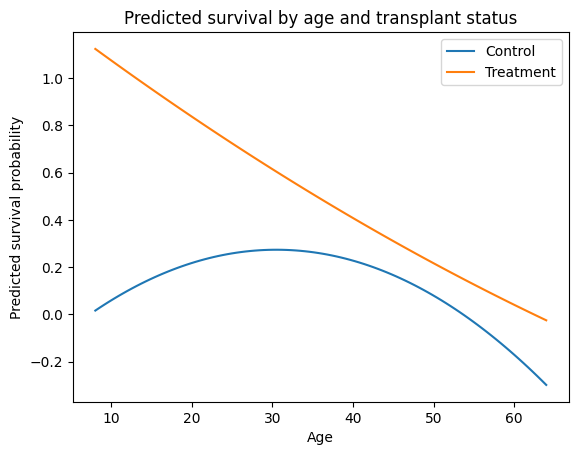

'\nFor part 4, the flexible model including nonlinear age terms and treatment interactions gives a test-set R^2 of 0.1812 and an RMSE of 0.4266. \nThis is an improvement over the simpler model, so allowing age effects to be nonlinear helps explain survival somewhat better. \nThe graph suggests that survival varies with age in a curved way, and the treatment group generally has higher predicted survival than the control group. \nThe gap between the two lines changes across age, suggesting that the effect of treatment may vary by age. \nOne limitation is that some predicted probabilities are above 1 or below 0, which shows a weakness of using linear regression for a binary outcome.\n'

In [69]:
# 4.4
# building a more flexible model with nonlinear age effects and interaction
heart['age2'] = heart['age']**2
heart['treat_age'] = heart['treatment'] * heart['age']
heart['treat_age2'] = heart['treatment'] * heart['age2']

# Train/Test Split
X = heart[['treatment', 'age', 'age2', 'treat_age', 'treat_age2']]
y = heart['y']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

reg3 = LinearRegression()
reg3.fit(X_train, y_train)

y_pred = reg3.predict(X_test)

r2 = reg3.score(X_test, y_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R^2:", r2)
print("RMSE:", rmse)

# plotting predicted survival by age for treatment and control
age_grid = np.linspace(heart['age'].min(), heart['age'].max(), 100)

control_df = pd.DataFrame({
    'treatment': 0,
    'age': age_grid,
    'age2': age_grid**2,
    'treat_age': 0,
    'treat_age2': 0
})

treat_df = pd.DataFrame({
    'treatment': 1,
    'age': age_grid,
    'age2': age_grid**2,
    'treat_age': age_grid,
    'treat_age2': age_grid**2
})

control_pred = reg3.predict(control_df)
treat_pred = reg3.predict(treat_df)

plt.plot(age_grid, control_pred, label='Control')
plt.plot(age_grid, treat_pred, label='Treatment')
plt.xlabel('Age')
plt.ylabel('Predicted survival probability')
plt.title('Predicted survival by age and transplant status')
plt.legend()
plt.show()


'''
For part 4, the flexible model including nonlinear age terms and treatment interactions gives a test-set R^2 of 0.1812 and an RMSE of 0.4266.
This is an improvement over the simpler model, so allowing age effects to be nonlinear helps explain survival somewhat better.
The graph suggests that survival varies with age in a curved way, and the treatment group generally has higher predicted survival than the control group.
The gap between the two lines changes across age, suggesting that the effect of treatment may vary by age.
One limitation is that some predicted probabilities are above 1 or below 0, which shows a weakness of using linear regression for a binary outcome.
'''

In [70]:
# 4.5
'''
My main concern is that a model like this could learn unfair patterns from historical data and then repeat them in future transplant decisions.
It may reflect unequal access to care or past bias rather than true medical need.
I am also concerned that a model reduces a very complex medical and ethical decision to a score, which could leave out important patient-specific information.
If deployed poorly, it could deny people a life-saving opportunity based on an imperfect prediction.
I think these models could maybe be used to assist doctors, but not to replace human judgment, and they would need transparency, bias testing, and careful oversight.
'''

'\nMy main concern is that a model like this could learn unfair patterns from historical data and then repeat them in future transplant decisions. \nIt may reflect unequal access to care or past bias rather than true medical need. \nI am also concerned that a model reduces a very complex medical and ethical decision to a score, which could leave out important patient-specific information. \nIf deployed poorly, it could deny people a life-saving opportunity based on an imperfect prediction. \nI think these models could maybe be used to assist doctors, but not to replace human judgment, and they would need transparency, bias testing, and careful oversight.\n'

**Q5.** This is a question about linear regression. The outcome is whether a defendant is held pre-trial in the Virginia justice system. We would like to understand how that outcome is predicted by characteristics of the defendant, particularly race. Let's be very careful/clear: We aren't saying anyone *should* be held without bond or asserting that people with different demographic variables *should* be more likely to be held, but instead trying to predict whether people with different characteristics *are empirically more likely* to be held without bond, given the available information. This is the first step we would take in investigating whether a system is fair, or how large the disparities are: Does it treat people with similar observable characteristics similarly, or not? We are going to look at a common question: Are Black defendants treated differently from white or Asian ones? (There are Native American defendants, but there are 11 in total, which is such a small number of observations that is difficult to clearly say anything about how this group is treated relative to the others.)

The variables in the data are:

  - `held_wo_bail`: Whether a defendant is held without bail before trial (Boolean logical)
  - `race`, `sex`: Categorical demographic variables
  - `is_poor`: Whether the defendant is classified as indigent
  - `prior_F`, `prior_M`: The number of prior felony and misdemeanor arrests
  - `case_type`: A categorical variable indicating a misdemeanor `M` or felony `F` or infraction `I` or special case `S`
  - `age`: Defendant's age
  - `bond`, `bond_NA`, `bond_type`: The amount of any bond, whether it is missing, and the type
  - `sentence`, `sentence_NA`, `sentence_type`: The length of any sentence, whether it is missing, and the type

1. Load the `pretrial_data.csv` data. Notice that there are `nan`s, but the data are relatively clean. Because there are `.nan`s among variables you won't use, you'll want to narrow down your analysis to the relevant variables before dropping or imputing missing values.
2. Create a dummy variable indicating that the defendant is Black.
3. Regress `held` on `Black`. What is the slope coefficient Interpret the coefficient on the Black dummy variable: How much more likely is a black person to be held without bail? What is the $R^2$ of the model?
4. Before doing this question, please think for a few minutes about how to make the process of running the following regressions as efficient as possible, before jumping into writing code. Repeat part 2, for the following specifications, keeping track of the coefficient on the Black dummy variable each time:
      - `held` on `Black` and `sex`
      - `held` on `Black` and `sex` and `is_poor`
      - `held` on `Black` and `sex` and `is_poor` and `prior_F`
      - `held` on `Black` and `sex` and `is_poor` and `prior_F` and `case_type`
What happens to the coefficient on the Black dummy variable as you include more regressors/features/controls in the regression? Explain your findings.
5. Suppose we don't want to see just `Black` and `sex`, but `Black` interacted with `sex`: Are Black men and Black women treated systemically differently from the rest of the population? Implement this in a regression, and explain your findings.
6. Imagine someone argued we should use these kinds of models to help a judge or magistrate make bail decisions (you could obviously go back and make this kind of model for the bond and sentence variables, then deploy it on new cases to predict what their bond and sentence values would be). What concerns would you have? Do you think society should be using data-driven and automated tools like that? Explain your concerns clearly.

**Q6.** Let's explore multiple linear regression in a two-variable case, to build more intuition about what is happening.

Suppose the model is
$$
\hat{y}_i = b_0 + b_1 z_{i1} + b_2 z_{i2}
$$
Assume that $z_{ij}$ is centered or de-meaned, so that $z_{ij} = x_{ij} - m_j$ where $m_j$ is the mean of variable $j$ and $x_{ij}$ is the original value of variable $j$ for observation $i$. Notice that this implies
$$
\dfrac{1}{N} \sum_{i=1}^N z_{ij} = 0
$$
which will simplify your calculations below substantially!

1. Write down the SSE for this model.
2. Take partial derivatives with respect to $b_0$, $b_1$, and $b_2$.
3. Verify that the average error is zero and $e \cdot z =0$ at the optimum, just as in the single linear regression case.
4. Show that the optimal intercept is $b_0^* = \bar{y}$. Eliminate $b_0^*$ from the remaining equations, and focus on $b_1$ and $b_2$.
5. Write your results as a matrix equation in the form "$Ab=C$". These are called the **normal equations**.
6. Divide both sides by $N$ and substitute $z_{ij} = x_{ij} - m_j$ back into your normal equations for $x_{ij}$. What is the matrix $A$? What is the vector $C$? Explain the intuition of your discovery.

**Q7.** In class, we showed that for the single linear regression model,
\begin{alignat*}{3}
a^* &=& \bar{y} \\
b^* &=& \dfrac{\sum_{i=1}^N(y_i - \bar{y})(x_i-\bar{x})}{\sum_{i=1}^N (x_i-\bar{x})^2},
\end{alignat*}

1. When will $b^*$ be large or small, depending on the relationship between $X$ and $Y$ and the variance of $X$?
2. Suppose you have measurement error in $X$ which artificially inflates its variance (e.g. bad data cleaning). We'll model this as saying the "real" value of $X$ for observation $i$ is $z_i$, but we observe $x_i = z_i + n_i$, where $n_i$ is the added noise. Does this affect the intercept of the regression? What happens to the $b^*$ coefficient relative to a noise-less model? How will affect your ability to predict? (This phenomenon is called **attenuation**.)
3. Suppose the noise $n_i$ is independent of $z_i$ and $y_i$, so that (approximately)
$$
\dfrac{1}{N} \sum_{i=1}^N (y_i - \bar{y})(n_i - \bar{n}) =0, \quad \dfrac{1}{N} \sum_{i=1}^N (z_i - \bar{z})(n_i - \bar{n}) =0.
$$
and that the mean of the bias is zero, so that
$$
\dfrac{1}{N} \sum_{i=1}^N n_i = 0.
$$
In this case, the noise $n_i$ is zero on average and independent of the values of $x_i$ and $y_i$: It's just measurement error or lazy data cleaning.
Explain the intuition of your result.

4. How does attenuation factor into the cost-benefit analysis of gathering higher quality data or cleaning it more carefully?

**Q8.**
1. Find a dataset on a topic you're interested in. Some easy options are data.gov, kaggle.com, and data.world.
2. Clean the data and do some exploratory data analysis on key variables that interest you. Pick a particular target/outcome variable and features/predictors.
3. Split the sample into an ~80% training set and a ~20% test set.
4. Run a few regressions of your target/outcome variable on a variety of features/predictors. Compute the SSE on the test set.
5. Which model performed the best, and why?
6. What did you learn?

**Q9.** There is a folder called `heart_failure` which contains reasonably detailed health data on patients and whether they die of congestive heart failure.

1. Load the data and perform an 80/20-train/test split.
2. Using dummy/one-hot-encoded variables and transformations of the numeric features, build the best model you can. **But**, do not delete code chunks or revise your work substantially as you experiment. Just keep moving forward with your ideas and experiments.
3. When you're done, scroll through your notebook. What worked and what didn't? Does your code have intention, or are you randomly experimenting? If you had to do this again, what might you do differently to get to a good model faster?


**Q10.** Let's look at a cousin of Linear Regression, called **kernel regression** or **local constant least squares** or **Nadaraya-Watson Estimator**.

We derived the OLS estimator for single linear regression by minimizing
$$
SSE(b_0, b_1) = \frac{1}{N}\sum_{i=1}^N (y_i - b_0 - b_1 x_i)^2
$$
with solution
$$
\hat{b}_0 = \bar{y} - \hat{b}_1 \bar{x}, \quad \hat{b}_1 = \dfrac{\frac{1}{N} \sum_{i=1}^N (x_i-\bar{x})(y_i - \bar{y})}{s_x^2}.
$$

When you step back and think about it, this is a bit weird: The algorithm is computing sample means, variances, and covariances, and using those to create a predictive model. The data themselves arguably vanish from the solution. This is elegant, this is strange.

Instead, let $k(z)$ be a kernel function, such as the Gaussian
$$
k(z) = \frac{1}{\sqrt{2\pi}} e^{-z^2/2}
$$
or uniform
$$
k(z) = \begin{cases}
1/2, & |z| \le \frac{1}{2}\\
0, & \text{otherwise.}
\end{cases}
$$
We'll instead minimize, or each predictor value $x$,
$$
SSE(\hat{y}(x)) = \dfrac{1}{N} \sum_{i=1}^N \left\lbrace y_i - \hat{y}(x)\right\rbrace^2 \dfrac{1}{h} k \left( \dfrac{x-x_i}{h} \right).
$$

1. Show that the optimal predictor is
$$
\hat{y}(x) = \dfrac{ \frac{1}{Nh} \sum_{i=1}^N  y_i k \left( \dfrac{x-x_i}{h} \right) }{\frac{1}{Nh} \sum_{i=1}^N k \left(  \dfrac{x-x_i}{h} \right)}
$$
This has many names, but let's call it the local constant least squares (LCLS) estimator, as opposed to ordinary least squares (OLS).

2. Compare and contrast LCLS with both OLS and $k$-Nearest Neighbor as a regression algorithm.

3. Write a function or class that implements the LCLS estimator for a single predictor variable $x$. For a default bandwidth $h$, you can use the maximum of the Silverman plug-ins for estimating kernel densities for $X$ and $Y$:
$$
h_y = 1.06 \times s_y^{-1/5}, \quad h_x = 1.06 \times s_x^{-1/5},
$$
$$
h = \max \{ h_y, h_x \}.
$$
For the kernel, you can hard-code the uniform, Gaussian, or Epanechnikov, or make it a parameter the user can adjust with a default choice.

4. For one of the datasets available for the homework, use your LCLS estimator from part 3 to predict values $\hat{y}(x_i)$ for each datapoint $x_i$. Plot your estimator $\hat{y}$ as a line over a scatterplot of the data $\{(x_i,y_i)\}_{i=1}^N$. Tune the bandwidth until you

5. Conceptually, how would you extend this analysis to a vector of predictors, $x = (x_1, ..., x_L)$ instead of just one explanatory variable $x$?
